In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def split_and_merge_simulations(simulation_paths):
    """
    Split clone IDs evenly across multiple simulations and merge selected clones.
    
    This function loads N simulation CSV files, determines the complete set of
    unique clone IDs in the *first* simulation, splits those clone IDs as evenly
    as possible across all N simulations, and merges together the corresponding
    subsets taken from each simulation file.

    Parameters
    ----------
    simulation_paths : list of str
        List of file paths to simulation CSV files.
        - All files must contain a "clone_id" column.
        - Assumes the same clone IDs appear in each simulation, but possibly 
          assigned to different states or having different observations.

    Returns
    -------
    pd.DataFrame
        A concatenated DataFrame containing:
        - The first 1/N of clone IDs from simulation 1,
        - The second 1/N of clone IDs from simulation 2,
        - ...
        - The last 1/N of clone IDs from simulation N.
        The order is determined by sorted clone IDs.

    Notes
    -----
    - Clone IDs are split *evenly* using integer division. 
      If the total number of clones is not exactly divisible by N, 
      the final chunk will contain the remainder.
    """
    
    # Load all simulations
    sims = [pd.read_csv(path) for path in simulation_paths]
    num_sims = len(sims)

    # Extract clone IDs from first simulation (assumed consistent)
    clone_ids = sorted(sims[0]["clone_id"].unique())
    total_clones = len(clone_ids)
    
    # Compute chunk size
    chunk_size = total_clones // num_sims
    remainder = total_clones % num_sims

    # Determine clone ID chunks for each simulation
    clone_chunks = []
    start = 0
    for i in range(num_sims):
        # distribute the remainder one-by-one to early chunks
        extra = 1 if i < remainder else 0
        end = start + chunk_size + extra
        clone_chunks.append(clone_ids[start:end])
        start = end

    # Merge the subsets
    merged_df = pd.concat(
        [
            sims[i][sims[i]["clone_id"].isin(clone_chunks[i])]
            for i in range(num_sims)
        ],
        ignore_index=True
    )

    return merged_df

In [47]:
sim_path_1 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B_high_k_on/df_rows_3_3_09082025_201359_ncells_6000_A_B_high_k_on_rep_0.csv"
sim_path_2 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B_low_k_on/df_rows_2_2_09082025_210256_ncells_6000_A_B_low_k_on_rep_0.csv"
sim = [sim_path_1, sim_path_2]
df = split_and_merge_simulations(sim)
# df = pd.read_csv(sim_path_1)

df_time_1 = df[df['time_step'] == 1]

In [45]:
sim_path_1 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_high_k_on/df_rows_3_3_09082025_220257_ncells_6000_A_to_B_high_k_on_rep_0.csv"
sim_path_2 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_low_k_on/df_rows_2_2_09082025_212311_ncells_6000_A_to_B_low_k_on_rep_0.csv"
sim = [sim_path_1, sim_path_2]
df = split_and_merge_simulations(sim)
# df = pd.read_csv(sim_path_1)
df_time_1 = df[df['time_step'] == 1]

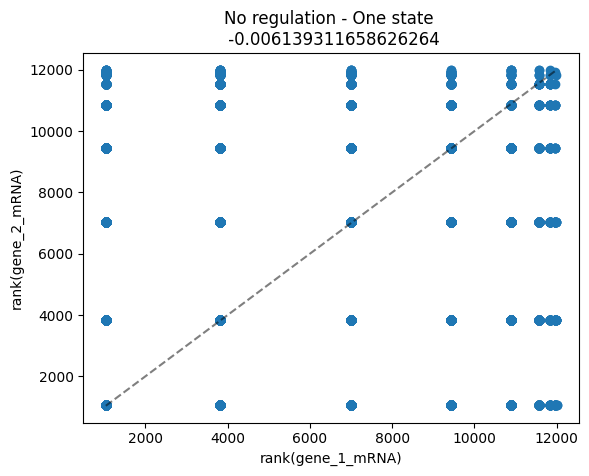

/tmp/ipykernel_3123308/4229737527.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_rank.groupby("x_bin")["ry"].mean()


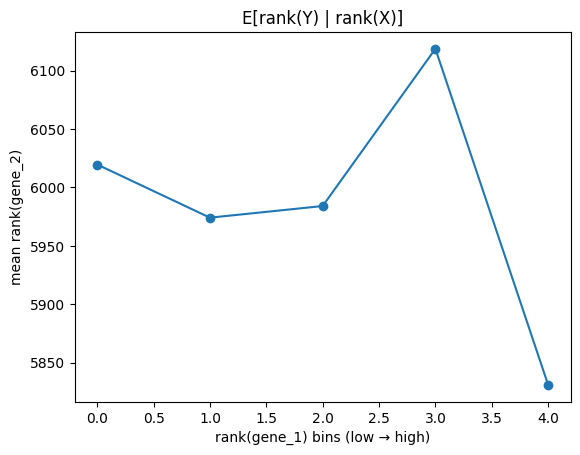

In [50]:
from scipy.stats import rankdata
import matplotlib.pyplot as plt

sim_path_1 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B_high_k_on/df_rows_3_3_09082025_201359_ncells_6000_A_B_high_k_on_rep_0.csv"
sim_path_2 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B_low_k_on/df_rows_2_2_09082025_210256_ncells_6000_A_B_low_k_on_rep_0.csv"
sim = [sim_path_1, sim_path_2]
df = pd.read_csv(sim_path_1)

df_time_1 = df[df['time_step'] == 1]

x = df_time_1['gene_1_mRNA']
y = df_time_1['gene_2_mRNA']
rx = rankdata(x, method="average")
ry = rankdata(y, method="average")

plt.scatter(rx, ry)
plt.xlabel("rank(gene_1_mRNA)")
plt.ylabel("rank(gene_2_mRNA)")
plt.plot([rx.min(), rx.max()], [rx.min(), rx.max()], "k--", alpha=0.5)
plt.title(f"No regulation - One state \n {spearmanr(x,y).correlation}")
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_rank = pd.DataFrame({"rx": rx, "ry": ry})
df_rank["x_bin"] = pd.qcut(df_rank["rx"], q=10, duplicates="drop")

summary = df_rank.groupby("x_bin")["ry"].mean()

plt.plot(range(len(summary)), summary, "o-")
plt.xlabel("rank(gene_1) bins (low → high)")
plt.ylabel("mean rank(gene_2)")
plt.title("E[rank(Y) | rank(X)]")
plt.show()


0.03437907753154787


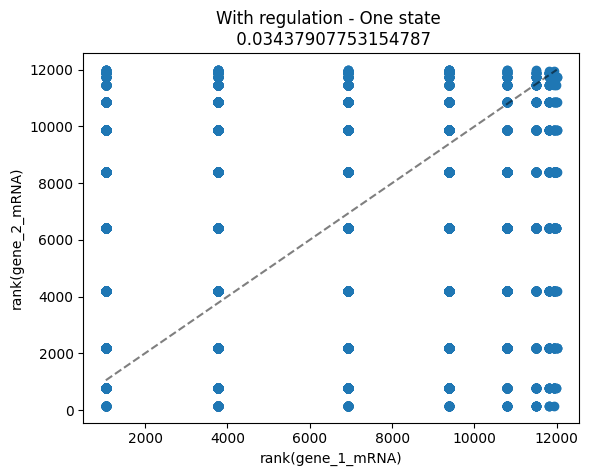

/tmp/ipykernel_3123308/647258265.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_rank.groupby("x_bin")["ry"].mean()


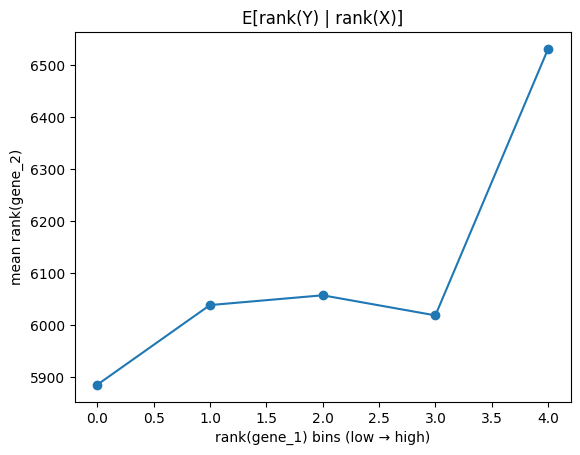

In [51]:
from scipy.stats import rankdata
import matplotlib.pyplot as plt

sim_path_1 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_high_k_on/df_rows_3_3_09082025_220257_ncells_6000_A_to_B_high_k_on_rep_0.csv"
sim_path_2 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_low_k_on/df_rows_2_2_09082025_212311_ncells_6000_A_to_B_low_k_on_rep_0.csv"
sim = [sim_path_1, sim_path_2]
df = pd.read_csv(sim_path_1)
df_time_1 = df[df['time_step'] == 1]

x = df_time_1['gene_1_mRNA']
y = df_time_1['gene_2_mRNA']
print(spearmanr(x,y).correlation)
rx = rankdata(x, method="average")
ry = rankdata(y, method="average")

plt.scatter(rx, ry)
plt.xlabel("rank(gene_1_mRNA)")
plt.ylabel("rank(gene_2_mRNA)")
plt.plot([rx.min(), rx.max()], [rx.min(), rx.max()], "k--", alpha=0.5)
plt.title(f"With regulation - One state \n {spearmanr(x,y).correlation}")
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_rank = pd.DataFrame({"rx": rx, "ry": ry})
df_rank["x_bin"] = pd.qcut(df_rank["rx"], q=10, duplicates="drop")

summary = df_rank.groupby("x_bin")["ry"].mean()

plt.plot(range(len(summary)), summary, "o-")
plt.xlabel("rank(gene_1) bins (low → high)")
plt.ylabel("mean rank(gene_2)")
plt.title("E[rank(Y) | rank(X)]")
plt.show()


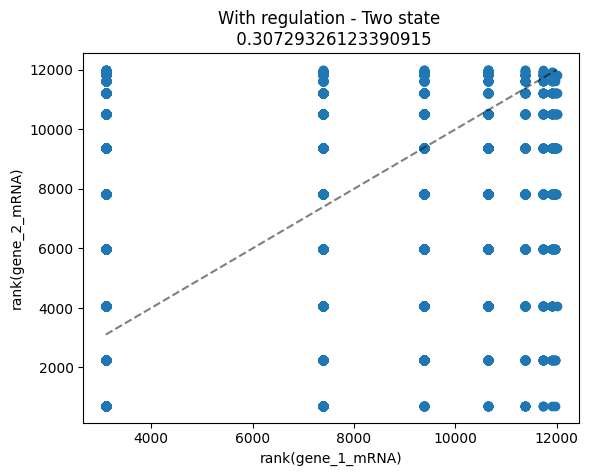

/tmp/ipykernel_3123308/1844194121.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_rank.groupby("x_bin")["ry"].mean()


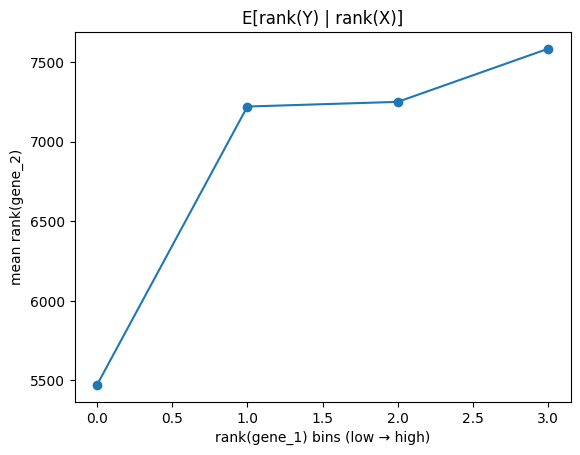

In [53]:
from scipy.stats import rankdata
import matplotlib.pyplot as plt
sim_path_1 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_high_k_on/df_rows_3_3_09082025_220257_ncells_6000_A_to_B_high_k_on_rep_0.csv"
sim_path_2 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_to_B_low_k_on/df_rows_2_2_09082025_212311_ncells_6000_A_to_B_low_k_on_rep_0.csv"
sim = [sim_path_1, sim_path_2]
df = split_and_merge_simulations(sim)
# df = pd.read_csv(sim_path_1)
df_time_1 = df[df['time_step'] == 1]

x = df_time_1['gene_1_mRNA']
y = df_time_1['gene_2_mRNA']
rx = rankdata(x, method="average")
ry = rankdata(y, method="average")

plt.scatter(rx, ry)
plt.xlabel("rank(gene_1_mRNA)")
plt.ylabel("rank(gene_2_mRNA)")
plt.plot([rx.min(), rx.max()], [rx.min(), rx.max()], "k--", alpha=0.5)
plt.title(f"With regulation - Two state \n {spearmanr(x,y).correlation}")
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_rank = pd.DataFrame({"rx": rx, "ry": ry})
df_rank["x_bin"] = pd.qcut(df_rank["rx"], q=10, duplicates="drop")

summary = df_rank.groupby("x_bin")["ry"].mean()

plt.plot(range(len(summary)), summary, "o-")
plt.xlabel("rank(gene_1) bins (low → high)")
plt.ylabel("mean rank(gene_2)")
plt.title("E[rank(Y) | rank(X)]")
plt.show()


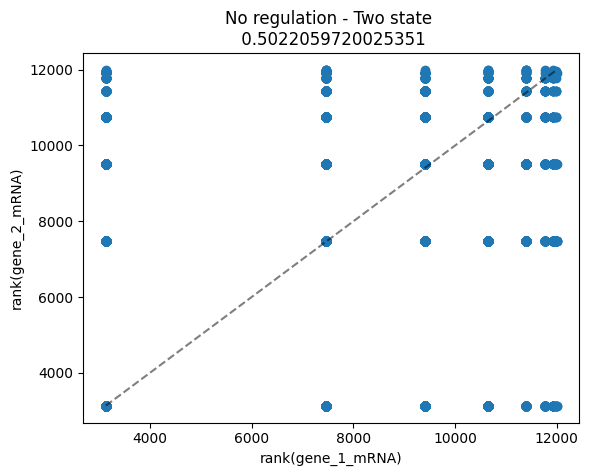

/tmp/ipykernel_3123308/4157932602.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_rank.groupby("x_bin")["ry"].mean()


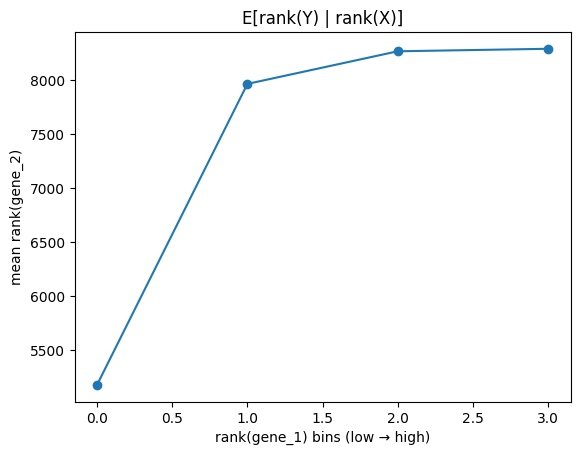

In [54]:
from scipy.stats import rankdata
import matplotlib.pyplot as plt
sim_path_1 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B_high_k_on/df_rows_3_3_09082025_201359_ncells_6000_A_B_high_k_on_rep_0.csv"
sim_path_2 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_2_simulations_6000_cells/A_B_low_k_on/df_rows_2_2_09082025_210256_ncells_6000_A_B_low_k_on_rep_0.csv"
sim = [sim_path_1, sim_path_2]
df = split_and_merge_simulations(sim)
# df = pd.read_csv(sim_path_1)

df_time_1 = df[df['time_step'] == 1]

x = df_time_1['gene_1_mRNA']
y = df_time_1['gene_2_mRNA']
rx = rankdata(x, method="average")
ry = rankdata(y, method="average")

plt.scatter(rx, ry)
plt.xlabel("rank(gene_1_mRNA)")
plt.ylabel("rank(gene_2_mRNA)")
plt.plot([rx.min(), rx.max()], [rx.min(), rx.max()], "k--", alpha=0.5)
plt.title(f"No regulation - Two state \n {spearmanr(x,y).correlation}")
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_rank = pd.DataFrame({"rx": rx, "ry": ry})
df_rank["x_bin"] = pd.qcut(df_rank["rx"], q=10, duplicates="drop")

summary = df_rank.groupby("x_bin")["ry"].mean()

plt.plot(range(len(summary)), summary, "o-")
plt.xlabel("rank(gene_1) bins (low → high)")
plt.ylabel("mean rank(gene_2)")
plt.title("E[rank(Y) | rank(X)]")
plt.show()
